# Third order Markov model for generating music
Database: [hansespinosa2 - 30000 Video Game MIDI Files](www.kaggle.com/datasets/hansespinosa2/40000-video-game-midi-files/data)

## Imports and constants

In [7]:
## Imports

from collections import Counter, defaultdict
from pathlib import Path
import json
import random
import pygame
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pretty_midi
import seaborn as sns
from IPython.display import display
import threading
import time
import re

## Constants

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

DATA_DIR = Path("data/hansespinosa2/40000-video-game-midi-files/versions/2")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)
IMAGE_DIR = Path("image/README")
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
MAX_FILES = 20000
MIN_NOTES_PER_FILE = 12
DURATION_GRID = 0.25
RHYTHM_GRID = 0.25
RARE_STATE_THRESHOLD = 2
LAPLACE_ALPHA = 0.05
TEMPERATURE = 0.9
MARKOV_ORDER = 3

print(f"Data: {DATA_DIR.resolve()}\nOutput: {OUTPUT_DIR.resolve()}")

Data: D:\Programiranje\etf_projekti\asm-projekat-x\data\hansespinosa2\40000-video-game-midi-files\versions\2
Output: D:\Programiranje\etf_projekti\asm-projekat-x\output


## Metadata creation

In [114]:
def midi_metadata(path):
    try:
        midi = pretty_midi.PrettyMIDI(str(path))
        return {
            "path": str(path),
            "duration_s": midi.get_end_time(),
            "tracks": len(midi.instruments),
            "instruments": [instr.name for instr in midi.instruments],
            "tempo_bpm": float(np.median(midi.get_tempo_changes()[1])) if len(midi.get_tempo_changes()[1]) else np.nan,
            "valid": True,
        }
    except Exception as error:
        return {"path": str(path), "duration_s": np.nan, "tracks": 0, "instruments": [], "tempo_bpm": np.nan, "valid": False, "error": str(error)}

In [115]:
midi_paths = sorted(
    path for path in DATA_DIR.rglob("*")
    if path.suffix.lower() in {".mid", ".midi"}
)
assert midi_paths, "No MIDI files found."
selected_paths = list(rng.choice(midi_paths, size=min(MAX_FILES, len(midi_paths)), replace=False))

metadata = pd.DataFrame(midi_metadata(path) for path in selected_paths)
valid_paths = [Path(path) for path in metadata.loc[metadata.valid, "path"]]
print(f"Found: {len(midi_paths)} | Sample: {len(selected_paths)} | Valid: {len(valid_paths)}")
display(metadata[metadata.valid].describe(include="all"))

c:\Users\Danilo\miniforge3\envs\faks_311\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Found: 12584 | Sample: 12584 | Valid: 12512


,path,duration_s,tracks,instruments,tempo_bpm,valid,error
count,12512,12512.000000,12512.000000,12512,12512.000000,12512,0
unique,12512,NaN,NaN,8627,NaN,1,0
top,data\hansespinosa2\40000-video-game-midi-files...,NaN,NaN,"[Original composer: ?, Sequenced by João *John...",NaN,True,NaN
freq,1,NaN,NaN,287,NaN,12512,NaN
mean,NaN,121.056582,7.954923,NaN,132.750337,NaN,NaN
std,NaN,159.330004,6.039307,NaN,41.387571,NaN,NaN
min,NaN,0.600000,1.000000,NaN,10.000000,NaN,NaN
25%,NaN,56.250000,4.000000,NaN,110.000110,NaN,NaN
50%,NaN,98.000000,7.000000,NaN,128.000000,NaN,NaN
75%,NaN,153.176121,10.000000,NaN,150.000000,NaN,NaN


In [116]:
metadata.to_pickle(OUTPUT_DIR / "metadata.pkl")

### Metadata import

In [8]:
metadata = pd.read_pickle(OUTPUT_DIR / "metadata.pkl")

In [9]:
display(metadata[metadata.valid][["path", "duration_s", "tracks", "tempo_bpm", "instruments"]])

,path,duration_s,tracks,tempo_bpm,instruments
0,data\hansespinosa2\40000-video-game-midi-files...,154.746704,14,151.990313,"[Synth Bass 2 (left), Synth Bass 2 (right), Di..."
1,data\hansespinosa2\40000-video-game-midi-files...,83.785631,2,140.000140,"[Staff, Staff-1]"
2,data\hansespinosa2\40000-video-game-midi-files...,261.403365,13,171.000094,"[from... er... Banjo-Tooie, from... er... Banj..."
3,data\hansespinosa2\40000-video-game-midi-files...,71.111040,9,162.000162,"[Drums, Fret Bass, Banjo, Flute, Pad 2, Fret B..."
4,data\hansespinosa2\40000-video-game-midi-files...,136.000000,10,120.000000,"[bass/snare, Cymbal, Heavy Timpanoes, Booming ..."
...,...,...,...,...,...
12579,data\hansespinosa2\40000-video-game-midi-files...,96.000000,5,120.000000,"[Staff, Staff-2, Staff-4, Staff-1, Staff-3]"
12580,data\hansespinosa2\40000-video-game-midi-files...,49.218750,4,128.000000,"[, , , ]"
12581,data\hansespinosa2\40000-video-game-midi-files...,78.444720,9,86.000052,"[11 - Music Box, 11 - Music Box, 11 - Music Bo..."
12582,data\hansespinosa2\40000-video-game-midi-files...,228.007708,10,120.000000,"[Maho Wave Drive, Waverunner Soft Brass, Bass ..."


## Preprocessing

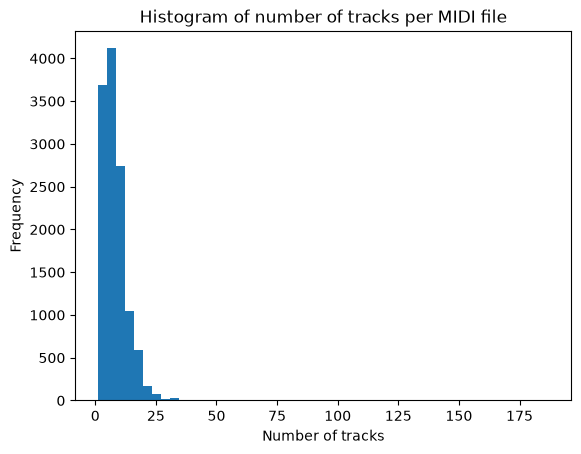

In [10]:
plt.hist(metadata.loc[metadata.valid, "tracks"], bins=50)
plt.xlabel("Number of tracks")
plt.ylabel("Frequency")
plt.title("Histogram of number of tracks per MIDI file")
plt.savefig(IMAGE_DIR / "histogram_num_of_tracks.png")
plt.show()

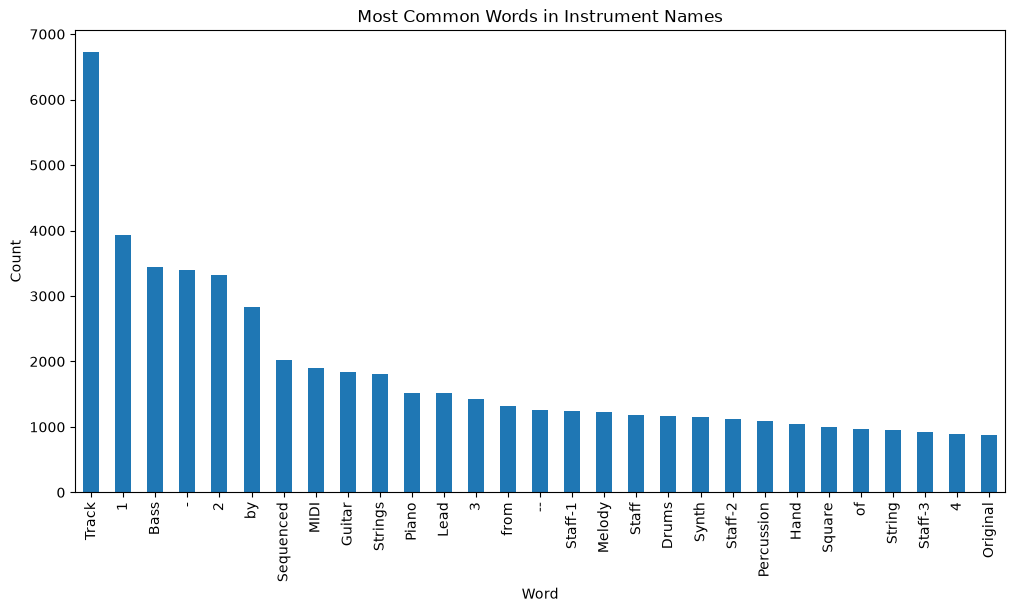

In [11]:
all_instruments = []
for midi in metadata[metadata.valid]["instruments"]:
    for instr in midi:
        all_instruments.extend(instr.split())

unique_instruments = pd.DataFrame({"instrument": all_instruments})
unique_instruments = unique_instruments[unique_instruments["instrument"].map(unique_instruments["instrument"].value_counts()) >= 800]
unique_instruments["instrument"].value_counts().plot(kind="bar", figsize=(12, 6))
plt.title("Most Common Words in Instrument Names")
plt.xlabel("Word")
plt.ylabel("Count")
plt.savefig(IMAGE_DIR / "histogram_common_words.png", bbox_inches="tight")
plt.show()

#### We will create a Markov model to generate bass lines for video game soundtracks

In [12]:
BASS_PROGRAMS = set(range(32, 40))
BASS_NAME_PATTERN = re.compile(r"\bbass\b", re.IGNORECASE)
NON_BASS_NAME_PATTERN = re.compile(r"bassoon|violin|viol|cello|drum|choir|voice|flute|horn|sax|trombone|clarinet|echo", re.IGNORECASE)

def name_looks_like_bass(name):
    name = name or ""
    return bool(BASS_NAME_PATTERN.search(name)) and not NON_BASS_NAME_PATTERN.search(name)

def is_bass_instrument(instrument):
    if instrument.is_drum:
        return False
    return instrument.program in BASS_PROGRAMS or name_looks_like_bass(instrument.name)


In [13]:
metadata = metadata[metadata.valid].copy()
metadata = metadata[metadata["instruments"].apply(lambda midi: any(name_looks_like_bass(instr) for instr in midi))]

print('Amount of MIDI files with bass:', len(metadata))
print('Amount of MIDI files with more than one bass instrument:', len(metadata[metadata["instruments"].apply(lambda midi: sum(name_looks_like_bass(instr) for instr in midi) > 1)]))

Amount of MIDI files with bass: 2732
Amount of MIDI files with more than one bass instrument: 844


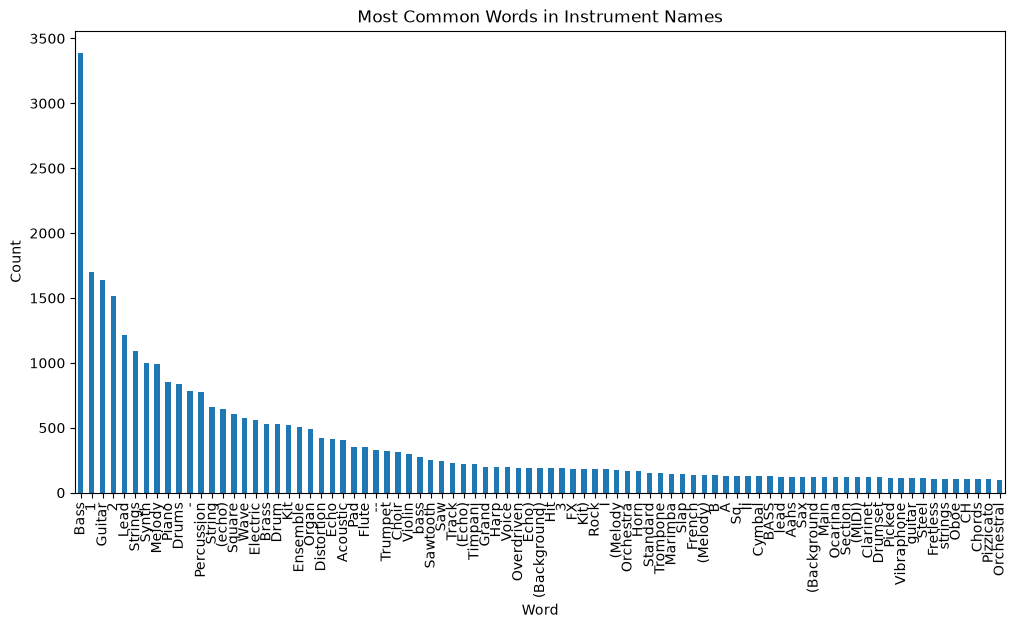

In [14]:
all_instruments = []
for midi in metadata[metadata.valid]["instruments"]:
    for instr in midi:
        all_instruments.extend(instr.split())

unique_instruments = pd.DataFrame({"instrument": all_instruments})
unique_instruments = unique_instruments[unique_instruments["instrument"].map(unique_instruments["instrument"].value_counts()) >= 100]
unique_instruments["instrument"].value_counts().plot(kind="bar", figsize=(12, 6))
plt.title("Most Common Words in Instrument Names")
plt.xlabel("Word")
plt.ylabel("Count")
plt.savefig(IMAGE_DIR / "histogram_bass_instruments.png", bbox_inches="tight")
plt.show()

Duration that contains more than 90% of files: 260.0


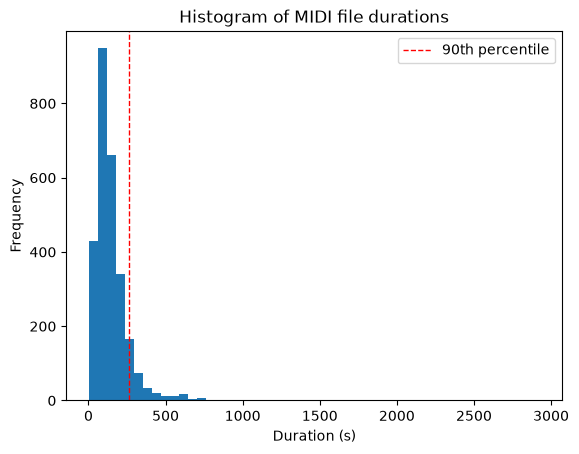

In [15]:
duration_90_percent = metadata.loc[metadata.valid, "duration_s"].quantile(0.9)
print('Duration that contains more than 90% of files:', duration_90_percent)

plt.hist(metadata.loc[metadata.valid, "duration_s"], bins=50)
plt.xlabel("Duration (s)")
plt.ylabel("Frequency")
plt.title("Histogram of MIDI file durations")
plt.axvline(duration_90_percent, color='r', linestyle='dashed', linewidth=1)
plt.legend(['90th percentile'])
plt.savefig(IMAGE_DIR / "histogram_duration.png")
plt.show()

In [16]:
metadata = metadata.loc[metadata["duration_s"] <= duration_90_percent]
valid_paths = [Path(path) for path in metadata["path"]]
print(f'Amount of valid MIDI files with duration <= {duration_90_percent}:', len(valid_paths))

Amount of valid MIDI files with duration <= 260.0: 2459


## Parsing MIDI files into an event sequence

In [17]:
def dominant_notes(path):
    try:
        midi = pretty_midi.PrettyMIDI(str(path))
        instruments = [instrument for instrument in midi.instruments if instrument.notes and is_bass_instrument(instrument)]
        if not instruments:
            return []
        notes = sorted(max(instruments, key=lambda instrument: len(instrument.notes)).notes, key=lambda note: (note.start, -note.pitch))
        melody = []
        for note in notes:
            if not melody or note.start >= melody[-1].end - 1e-4:
                melody.append(note)
            elif note.pitch > melody[-1].pitch:
                melody[-1] = note
        return melody
    except Exception:
        return []

In [18]:
raw_sequences = [(path, dominant_notes(path)) for path in valid_paths]
raw_sequences = [(path, notes) for path, notes in raw_sequences if len(notes) >= MIN_NOTES_PER_FILE]
print(f"Sequences with at least {MIN_NOTES_PER_FILE} notes: {len(raw_sequences)}")

c:\Users\Danilo\miniforge3\envs\faks_311\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Sequences with at least 12 notes: 2417


## Extraction of characteristics

In [19]:
PITCH_CLASSES = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]

def quantize(value, grid):
    return max(grid, round(value / grid) * grid)

def notes_to_events(notes):
    events = []
    for index, note in enumerate(notes):
        next_start = notes[index + 1].start if index + 1 < len(notes) else note.end
        events.append({
            "pitch": int(note.pitch),
            "duration": quantize(note.end - note.start, DURATION_GRID),
            "onset_gap": quantize(max(0, next_start - note.start), RHYTHM_GRID),
            "chord": PITCH_CLASSES[note.pitch % 12],
        })
    return events

In [20]:
event_sequences = [(path, notes_to_events(notes)) for path, notes in raw_sequences]
print("Event sequence sample:", event_sequences[0][1][:4])

Event sequence sample: [{'pitch': 35, 'duration': 0.25, 'onset_gap': 0.25, 'chord': 'B'}, {'pitch': 35, 'duration': 0.25, 'onset_gap': 0.25, 'chord': 'B'}, {'pitch': 35, 'duration': 0.25, 'onset_gap': 0.25, 'chord': 'B'}, {'pitch': 35, 'duration': 0.25, 'onset_gap': 0.25, 'chord': 'B'}]


## State discretization and tokenization

In [21]:
UNK = ("UNK", "UNK", "UNK", "UNK")

def event_token(event):
    return (event["pitch"], event["duration"], event["onset_gap"], event["chord"])

def encode_sequence(sequence):
    return [token if token_counts[token] >= RARE_STATE_THRESHOLD else UNK for token in map(event_token, sequence)]

In [22]:
all_tokens = [event_token(event) for _, sequence in event_sequences for event in sequence]
token_counts = Counter(all_tokens)

encoded_sequences = [encode_sequence(sequence) for _, sequence in event_sequences]
states = sorted(set(token for sequence in encoded_sequences for token in sequence), key=str)
state_to_index = {state: index for index, state in enumerate(states)}
index_to_state = {index: state for state, index in state_to_index.items()}
encoded_indices = [[state_to_index[token] for token in sequence] for sequence in encoded_sequences]
print(f"Number of states: {len(states)} | Number of tokens: {len(all_tokens)}")

Number of states: 1908 | Number of tokens: 1040935


## Training

In [23]:
def build_ngram_counts(sequences, order):
    counts = defaultdict(Counter)
    for sequence in sequences:
        for index in range(len(sequence) - order):
            context = tuple(sequence[index:index + order])
            next_state = sequence[index + order]
            counts[context][next_state] += 1
    return counts

def train_markov(sequences, n_states, order=MARKOV_ORDER, alpha=LAPLACE_ALPHA):
    unigram = np.full(n_states, alpha, dtype=float)
    for sequence in sequences:
        for state in sequence:
            unigram[state] += 1
    unigram /= unigram.sum()

    order_counts = {level: build_ngram_counts(sequences, level) for level in range(1, order + 1)}
    initial_contexts = Counter(tuple(sequence[:order]) for sequence in sequences if len(sequence) >= order)
    return unigram, order_counts, initial_contexts

def serialize_counts(counts):
    return {"|".join(map(str, context)): dict(counter) for context, counter in counts.items()}


In [24]:
unigram_probs, transition_counts, initial_contexts = train_markov(encoded_indices, len(states))
assert np.allclose(unigram_probs.sum(), 1)

model_payload = {
    "order": MARKOV_ORDER,
    "alpha": LAPLACE_ALPHA,
    "unigram": unigram_probs.tolist(),
    "transition_counts": {level: serialize_counts(counts) for level, counts in transition_counts.items()},
    "initial_contexts": {"|".join(map(str, context)): count for context, count in initial_contexts.items()},
}
with open(OUTPUT_DIR / "markov_model.json", "w", encoding="utf-8") as output_file:
    json.dump(model_payload, output_file, ensure_ascii=False)
with open(OUTPUT_DIR / "states.json", "w", encoding="utf-8") as output_file:
    json.dump([list(state) for state in states], output_file, ensure_ascii=False)
print(f"Model saved. Number of contexts per order:", {level: len(counts) for level, counts in transition_counts.items()})

Model saved. Number of contexts per order: {1: 1905, 2: 19749, 3: 56846}


## Data sparsity and rare-state collapsing

In [25]:
rare_token_share = np.mean([count < RARE_STATE_THRESHOLD for count in token_counts.values()])
unk_token_share = np.mean([token == UNK for sequence in encoded_sequences for token in sequence])
singleton_context_shares = {
    level: np.mean([sum(counts.values()) == 1 for counts in level_counts.values()])
    for level, level_counts in transition_counts.items()
}
print(f"Unique raw (pitch, duration, gap, chord) tokens: {len(token_counts)}")
print(f"Share of unique tokens that occur < {RARE_STATE_THRESHOLD} times (collapsed to UNK): {rare_token_share:.1%}")
print(f"Share of all training tokens that end up as UNK: {unk_token_share:.1%}")
print("Share of contexts seen exactly once, per order:", {level: f"{share:.1%}" for level, share in singleton_context_shares.items()})


Unique raw (pitch, duration, gap, chord) tokens: 2568
Share of unique tokens that occur < 2 times (collapsed to UNK): 25.7%
Share of all training tokens that end up as UNK: 0.1%
Share of contexts seen exactly once, per order: {1: '0.4%', 2: '17.8%', 3: '19.7%'}


## Bass line generation

In [26]:
def tempered(probabilities, temperature=TEMPERATURE):
    logits = np.log(np.clip(probabilities, 1e-12, None)) / temperature
    weights = np.exp(logits - logits.max())
    return weights / weights.sum()

def context_distribution(context, order, temperature):
    """Vraca (stanja, verovatnoce) za dati kontekst, uz backoff na krace kontekste i unigram."""
    for level in range(order, 0, -1):
        sub_context = context[-level:]
        counts = transition_counts[level].get(sub_context)
        if counts:
            next_states = np.array(list(counts.keys()))
            counts_arr = np.full(len(next_states), LAPLACE_ALPHA, dtype=float) + np.array(list(counts.values()), dtype=float)
            return next_states, tempered(counts_arr / counts_arr.sum(), temperature)
    all_states = np.arange(len(unigram_probs))
    return all_states, tempered(unigram_probs, temperature)

def sample_initial_context(order, temperature):
    contexts = list(initial_contexts.keys())
    weights = np.array(list(initial_contexts.values()), dtype=float)
    weights = tempered(weights / weights.sum(), temperature)
    chosen = contexts[rng.choice(len(contexts), p=weights)]
    return list(chosen)

def generate_indices(length=80, temperature=TEMPERATURE, order=MARKOV_ORDER):
    generated = sample_initial_context(order, temperature)
    for _ in range(length - len(generated)):
        context = tuple(generated[-order:])
        next_states, probabilities = context_distribution(context, order, temperature)
        generated.append(int(rng.choice(next_states, p=probabilities)))
    return generated[:length]

non_unk_indices = np.array([index for index, state in index_to_state.items() if state != UNK])
non_unk_weights = unigram_probs[non_unk_indices] / unigram_probs[non_unk_indices].sum()

def decode_indices(indices):
    decoded = []
    for index in indices:
        state = index_to_state[index]
        if state == UNK:
            state = index_to_state[int(rng.choice(non_unk_indices, p=non_unk_weights))]
        decoded.append(state)
    return decoded


In [27]:
generated_indices = generate_indices(length=96)
generated_tokens = decode_indices(generated_indices)
print("First ten generated states:", generated_tokens[:10])

First ten generated states: [(48, 0.25, 0.25, 'C'), (48, 0.25, 1.0, 'C'), (43, 0.25, 0.25, 'G'), (48, 0.25, 0.5, 'C'), (48, 0.25, 0.5, 'C'), (50, 0.25, 0.5, 'D'), (50, 0.25, 0.5, 'D'), (50, 0.25, 0.5, 'D'), (50, 0.25, 0.5, 'D'), (48, 0.25, 0.5, 'C')]


## Postprocessing and MIDI translation

In [28]:
def tokens_to_midi(tokens, tempo=120):
    result = pretty_midi.PrettyMIDI(initial_tempo=tempo)
    instrument = pretty_midi.Instrument(program=pretty_midi.instrument_name_to_program("Acoustic Grand Piano"))
    onset = 0.0
    for pitch, duration, onset_gap, _ in tokens:
        pitch = int(np.clip(pitch, 36, 96))
        duration = max(float(duration), DURATION_GRID)
        gap = max(float(onset_gap), RHYTHM_GRID)
        instrument.notes.append(pretty_midi.Note(velocity=88, pitch=pitch, start=onset, end=onset + duration))
        onset += gap
    result.instruments.append(instrument)
    return result

TEMPERATURES = [0.5, 0.5, 0.7, 0.7, 0.9, 0.9, 1, 1, 1.15, 1.15, 1.5, 1.5]

In [29]:
generated_collections = [decode_indices(generate_indices(96, temperature)) for temperature in TEMPERATURES]
for index, tokens in enumerate(generated_collections, start=1):
    tokens_to_midi(tokens).write(str(OUTPUT_DIR / f"generated_T{TEMPERATURES[index-1]}_{index}.mid"))

preview = tokens_to_midi(generated_collections[1])
print("Saved MIDI examples:", list(OUTPUT_DIR.glob("generated_*.mid")))

Saved MIDI examples: [WindowsPath('output/generated_T0.5_1.mid'), WindowsPath('output/generated_T0.5_2.mid'), WindowsPath('output/generated_T0.7_3.mid'), WindowsPath('output/generated_T0.7_4.mid'), WindowsPath('output/generated_T0.9_5.mid'), WindowsPath('output/generated_T0.9_6.mid'), WindowsPath('output/generated_T1.15_10.mid'), WindowsPath('output/generated_T1.15_9.mid'), WindowsPath('output/generated_T1.5_11.mid'), WindowsPath('output/generated_T1.5_12.mid'), WindowsPath('output/generated_T1_7.mid'), WindowsPath('output/generated_T1_8.mid')]


## Model evaluation

In [30]:
def feature_values(sequences):
    events = [event for sequence in sequences for event in sequence]
    pitches = [event["pitch"] for event in events]
    intervals = [second - first for sequence in sequences for first, second in zip([event["pitch"] for event in sequence], [event["pitch"] for event in sequence][1:])]
    durations = [event["duration"] for event in events]
    chords = [event["chord"] for event in events]
    return {"pitch": pitches, "interval": intervals, "duration": durations, "chord": chords}

def entropy(values):
    probabilities = np.array(list(Counter(values).values()), dtype=float)
    probabilities /= probabilities.sum()
    return float(-(probabilities * np.log2(probabilities)).sum())

def ngrams(values, n=3):
    return set(tuple(values[index:index+n]) for index in range(len(values) - n + 1))

def jaccard(first, second):
    return len(first & second) / len(first | second) if first | second else np.nan

def tokens_to_events(tokens):
    return [{"pitch": int(pitch), "duration": float(duration), "onset_gap": float(gap), "chord": chord} for pitch, duration, gap, chord in tokens]

In [31]:
original_features = feature_values([sequence for _, sequence in event_sequences])
generated_event_sequences = [tokens_to_events(tokens) for tokens in generated_collections]
generated_features = feature_values(generated_event_sequences)
metrics = pd.DataFrame([
    {"group": "original", "pitch_entropy": entropy(original_features["pitch"]), "interval_entropy": entropy(original_features["interval"]), "duration_entropy": entropy(original_features["duration"]), "3-gram_Jaccard": 1.0},
    {"group": "generated", "pitch_entropy": entropy(generated_features["pitch"]), "interval_entropy": entropy(generated_features["interval"]), "duration_entropy": entropy(generated_features["duration"]), "3-gram_Jaccard": jaccard(ngrams(original_features["pitch"]), ngrams(generated_features["pitch"]))},
])
display(metrics.round(3))

,group,pitch_entropy,interval_entropy,duration_entropy,3-gram_Jaccard
0,original,5.05,3.481,0.457,1.000
1,generated,4.29,3.339,1.025,0.024


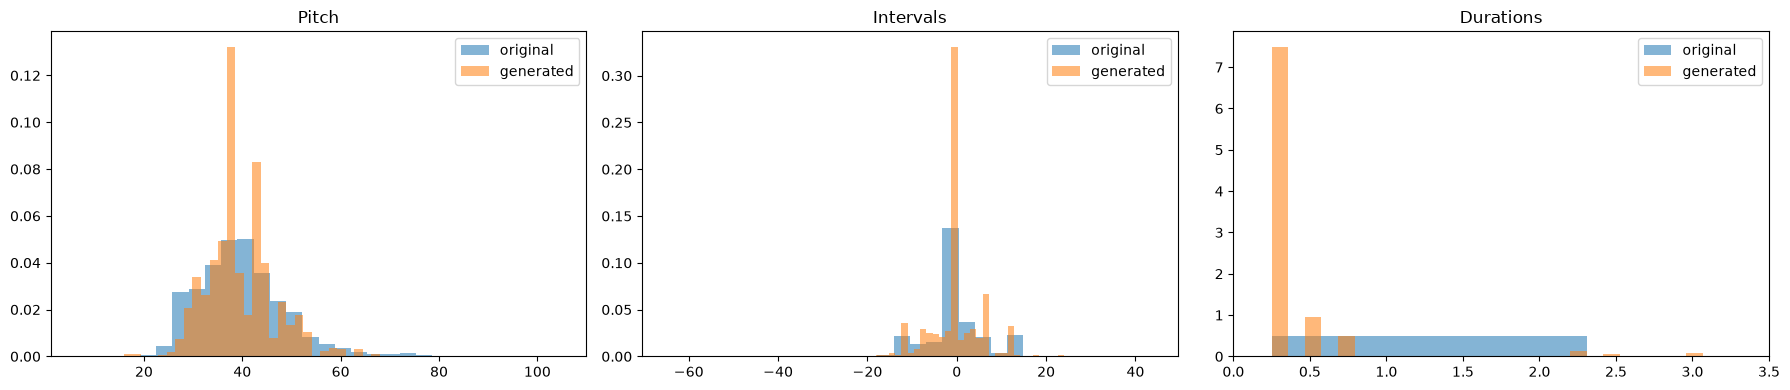

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for axis, feature, title in zip(axes, ["pitch", "interval", "duration"], ["Pitch", "Intervals", "Durations"]):
    axis.hist(original_features[feature], bins=30, density=True, alpha=0.55, label="original")
    axis.hist(generated_features[feature], bins=30, density=True, alpha=0.55, label="generated")
    if feature == "duration":
        axis.set_xlim(0, max(generated_features["duration"]))
    axis.set_title(title)
    axis.legend()
plt.tight_layout()
plt.savefig(IMAGE_DIR / "histogram_comparison.png")
plt.show()

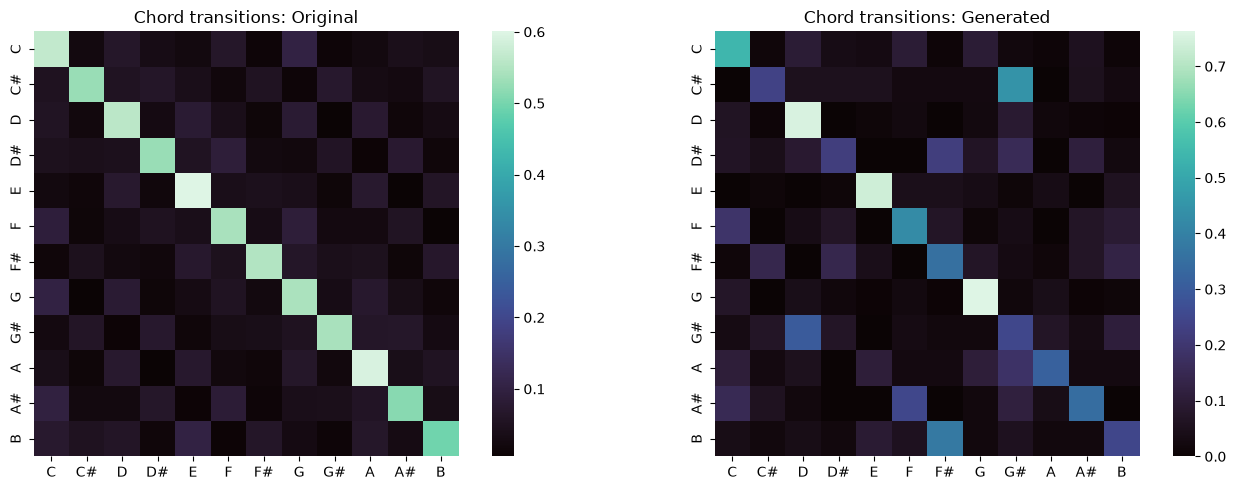

In [33]:
def chord_transition_matrix(chords):
    matrix = pd.DataFrame(0, index=PITCH_CLASSES, columns=PITCH_CLASSES, dtype=float)
    for current_chord, next_chord in zip(chords, chords[1:]):
        matrix.loc[current_chord, next_chord] += 1
    return matrix.div(matrix.sum(axis=1).replace(0, 1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for axis, chords, title in zip(axes, [original_features["chord"], generated_features["chord"]], ["Original", "Generated"]):
    sns.heatmap(chord_transition_matrix(chords), cmap="mako", ax=axis, square=True)
    axis.set_title(f"Chord transitions: {title}")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "note_transitions.png")
plt.show()

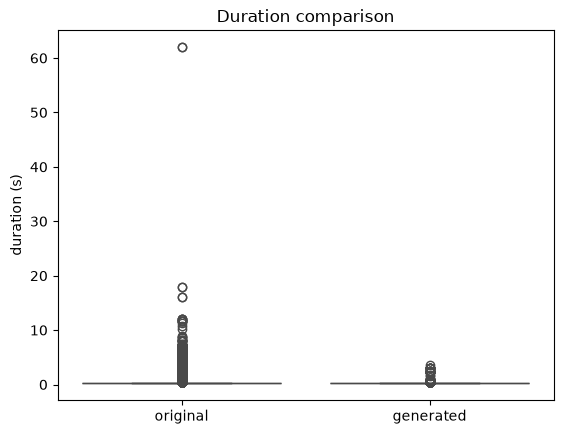

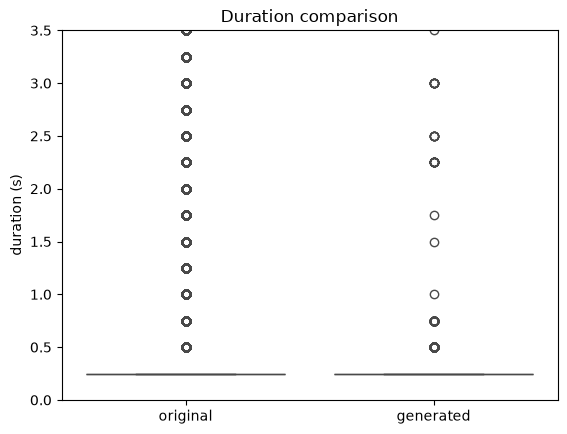

In [36]:
comparison = pd.DataFrame({
    "original": pd.Series(original_features["duration"]),
    "generated": pd.Series(generated_features["duration"]),
})
for i in range(2):
    sns.boxplot(data=comparison, palette=["#4C78A8", "#F58518"], order=["original", "generated"])
    plt.title("Duration comparison")
    plt.ylabel("duration (s)")
    if i == 1:
        plt.ylim(0, max(generated_features["duration"]))
    else:
        plt.savefig(IMAGE_DIR / "duration_comparison.png")
    plt.show()

### Held-out perplexity

In [69]:
def split_sequences(sequences, test_fraction=0.2, seed=SEED):
    shuffled_indices = list(range(len(sequences)))
    random.Random(seed).shuffle(shuffled_indices)
    n_test = max(1, int(len(sequences) * test_fraction))
    test_positions = set(shuffled_indices[:n_test])
    train = [sequence for position, sequence in enumerate(sequences) if position not in test_positions]
    test = [sequence for position, sequence in enumerate(sequences) if position in test_positions]
    return train, test

def token_probability(context, next_state, order, transition_counts_local, unigram_local, alpha=LAPLACE_ALPHA):
    for level in range(min(order, len(context)), 0, -1):
        sub_context = tuple(context[-level:])
        counts = transition_counts_local.get(level, {}).get(sub_context)
        if counts and next_state in counts:
            total = sum(counts.values()) + alpha * len(counts)
            return (counts[next_state] + alpha) / total
    return unigram_local[next_state]

def perplexity(sequences, order, transition_counts_local, unigram_local):
    log_probs = [
        np.log2(token_probability(sequence[max(0, index - order):index], sequence[index], order, transition_counts_local, unigram_local))
        for sequence in sequences
        for index in range(1, len(sequence))
    ]
    return 2 ** (-np.mean(log_probs))

train_sequences, test_sequences = split_sequences(encoded_indices)
train_unigram, train_transition_counts, train_initial_contexts = train_markov(train_sequences, len(states))

markov_perplexity = perplexity(test_sequences, MARKOV_ORDER, train_transition_counts, train_unigram)
baseline_perplexity = perplexity(test_sequences, 0, {}, train_unigram)

print(f"Train songs: {len(train_sequences)} | Held-out test songs: {len(test_sequences)}")
print(f"Held-out perplexity, order-{MARKOV_ORDER} model with backoff: {markov_perplexity:.1f}")
print(f"Held-out perplexity, unigram-only baseline: {baseline_perplexity:.1f}")
print(f"Number of possible states: {len(states)}")


Train songs: 1934 | Held-out test songs: 483
Held-out perplexity, order-3 model with backoff: 9.9
Held-out perplexity, unigram-only baseline: 66.2
Number of possible states: 1908


### Novelty check

In [ ]:
def ngram_set(sequences, n):
    return set(tuple(sequence[index:index + n]) for sequence in sequences for index in range(len(sequence) - n + 1))

def generate_indices_from_model(transition_counts_local, unigram_local, initial_contexts_local, length=80, temperature=TEMPERATURE, order=MARKOV_ORDER):
    def local_context_distribution(context):
        for level in range(order, 0, -1):
            counts = transition_counts_local[level].get(context[-level:])
            if counts:
                next_states = np.array(list(counts.keys()))
                counts_arr = np.full(len(next_states), LAPLACE_ALPHA, dtype=float) + np.array(list(counts.values()), dtype=float)
                return next_states, tempered(counts_arr / counts_arr.sum(), temperature)
        return np.arange(len(unigram_local)), tempered(unigram_local, temperature)

    contexts = list(initial_contexts_local.keys())
    weights = tempered(np.array(list(initial_contexts_local.values()), dtype=float), temperature)
    generated = list(contexts[rng.choice(len(contexts), p=weights)])
    for _ in range(length - len(generated)):
        next_states, probabilities = local_context_distribution(tuple(generated[-order:]))
        generated.append(int(rng.choice(next_states, p=probabilities)))
    return generated[:length]

N_CHECK = MARKOV_ORDER + 2
train_ngrams = ngram_set(train_sequences, N_CHECK)
test_ngrams = ngram_set(test_sequences, N_CHECK)

baseline_windows = [tuple(sequence[index:index + N_CHECK]) for sequence in test_sequences for index in range(len(sequence) - N_CHECK + 1)]
baseline_overlap = np.mean([window in train_ngrams for window in baseline_windows])
print(f"Baseline: share of real held-out {N_CHECK}-grams that already appear in the train set: {baseline_overlap:.3f}")

novelty_rows = []
for temperature in sorted(set(TEMPERATURES)):
    generated_sample = generate_indices_from_model(train_transition_counts, train_unigram, train_initial_contexts, length=96, temperature=temperature)
    windows = [tuple(generated_sample[index:index + N_CHECK]) for index in range(len(generated_sample) - N_CHECK + 1)]
    train_overlap = np.mean([window in train_ngrams for window in windows])
    test_overlap = np.mean([window in test_ngrams for window in windows])
    novelty_rows.append({
        "temperature": temperature,
        f"{N_CHECK}-gram_overlap_with_train": round(train_overlap, 3),
        f"{N_CHECK}-gram_overlap_with_test": round(test_overlap, 3),
    })

display(pd.DataFrame(novelty_rows))


Baseline: share of real held-out 5-grams that already appear in the train set: 0.540


,temperature,5-gram_overlap_with_train,5-gram_overlap_with_test
0,0.50,1.000,1.000
1,0.70,0.913,0.707
2,0.90,0.924,0.750
3,1.00,0.815,0.011
4,1.15,0.761,0.185
5,1.50,0.870,0.011


## Divergence over time

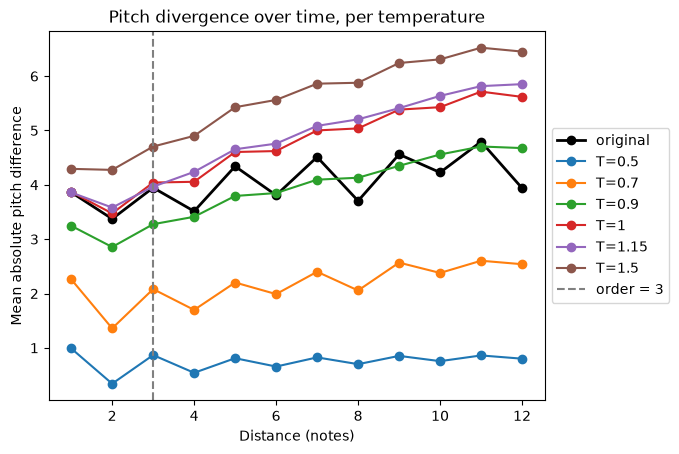

In [ ]:
def divergence(sequences, max_lag=12):
    divergences = []
    for distance in range(1, max_lag + 1):
        pitch_diffs = [
            abs(index_to_state[seq[i + distance]][0] - index_to_state[seq[i]][0])
            for seq in sequences for i in range(len(seq) - distance)
            if index_to_state[seq[i]] != UNK and index_to_state[seq[i + distance]] != UNK
        ]
        divergences.append(np.mean(pitch_diffs) if pitch_diffs else np.nan)
    return divergences

original_divergence = divergence(encoded_indices, MIN_NOTES_PER_FILE)

plt.plot(range(1, MIN_NOTES_PER_FILE + 1), original_divergence, marker="o", label="original", color="black", linewidth=2)
for temperature in sorted(set(TEMPERATURES)):
    temperature_sequences = [generate_indices(96, temperature) for _ in range(100)]
    temperature_divergence = divergence(temperature_sequences, MIN_NOTES_PER_FILE)
    plt.plot(range(1, MIN_NOTES_PER_FILE + 1), temperature_divergence, marker="o", label=f"T={temperature}")

plt.axvline(MARKOV_ORDER, color="gray", linestyle="--", label=f"order = {MARKOV_ORDER}")
plt.xlabel("Distance (notes)")
plt.ylabel("Mean absolute pitch difference")
plt.title("Pitch divergence over time, per temperature")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig(IMAGE_DIR / "pitch_divergence.png")
plt.show()

## Listening section

In [41]:
def play_music(music_file):
    clock = pygame.time.Clock()
    try:
        pygame.mixer.music.load(music_file)
        print("Music file %s loaded!" % music_file)
    except pygame.error:
        print("File %s not found! (%s)" % (music_file, pygame.get_error()))
        return
    pygame.mixer.music.play()
    while pygame.mixer.music.get_busy():
        clock.tick(30)

def play_for_10_seconds(midi_file):
    thread = threading.Thread(target=play_music, args=(midi_file,))
    thread.start()
    time.sleep(10)
    pygame.mixer.music.stop()
    thread.join()
    
def plot_midi(file_path):
    midi_data = pretty_midi.PrettyMIDI(file_path)
    plt.figure(figsize=(10, 4))
    for instrument in midi_data.instruments:
        for note in instrument.notes:
            plt.plot([note.start, note.end], [note.pitch, note.pitch], linewidth=2)
    plt.xlim(0, 10)
    plt.xlabel('Time (s)')
    plt.ylabel('Pitch')
    plt.title(file_path)
    plt.show()

def plot_midi_subplot(file_path, ax):
    midi_data = pretty_midi.PrettyMIDI(file_path)
    for instrument in midi_data.instruments:
        for note in instrument.notes:
            ax.plot([note.start, note.end], [note.pitch, note.pitch], linewidth=2)
    ax.set_xlim(0, 20)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Pitch')
    ax.set_title(file_path)

freq = 44100
bitsize = -16
channels = 2
buffer = 1024
pygame.mixer.init(freq, bitsize, channels, buffer)
pygame.mixer.music.set_volume(0.8)

Example of the dataset midi file
Music file example.mid loaded!


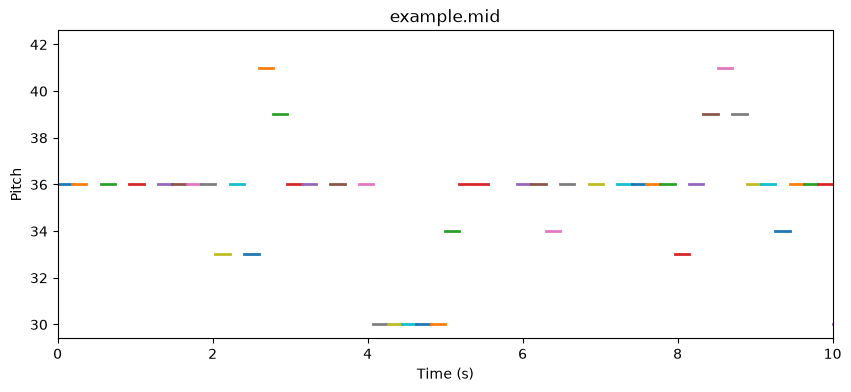

In [151]:
print("Example of the dataset midi file")
midi_file = metadata.loc[metadata.valid, "path"].iloc[1]
example_midi = pretty_midi.PrettyMIDI(str(midi_file))
example_midi.instruments = [instrument for instrument in example_midi.instruments if instrument.notes and is_bass_instrument(instrument)]
example_midi.instruments = example_midi.instruments[:1]
example_midi.write(str('example.mid'))
play_for_10_seconds('example.mid')
plot_midi('example.mid')

Example of the generated midi file with temperature 0.5
Music file output/generated_T0.5_2.mid loaded!


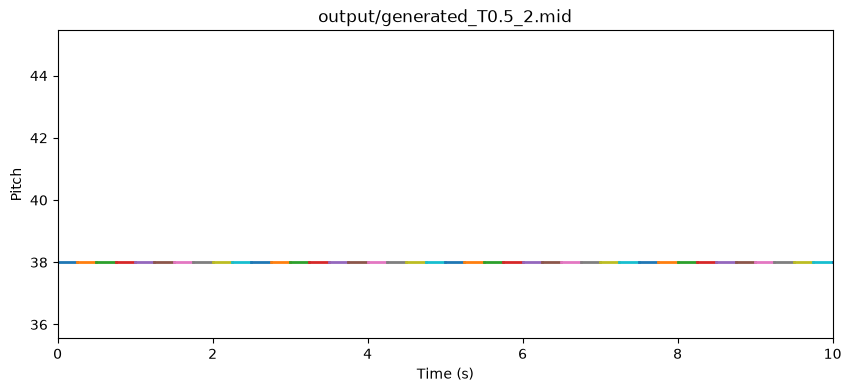

In [152]:
print("Example of the generated midi file with temperature 0.5")
generated_midi_file = "output/generated_T0.5_2.mid"
midi = pretty_midi.PrettyMIDI(str(generated_midi_file))
for instrument in midi.instruments:
    instrument.name = example_midi.instruments[0].name
    instrument.program = example_midi.instruments[0].program
midi.write(str(generated_midi_file))
play_for_10_seconds(generated_midi_file)
plot_midi(generated_midi_file)

Example of the generated midi file with temperature 1
Music file output/generated_T1_7.mid loaded!


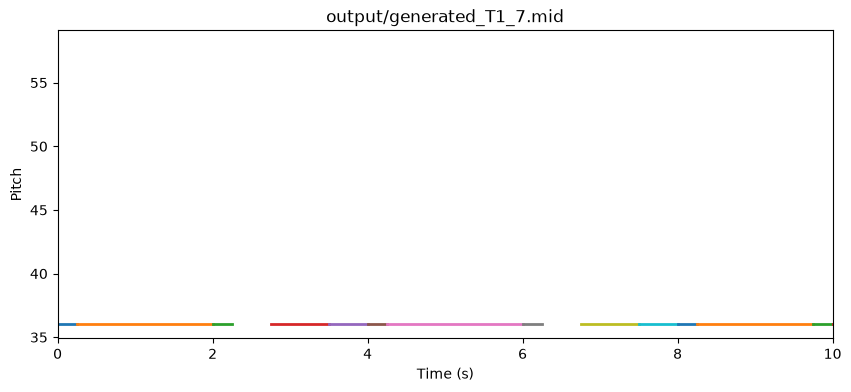

In [153]:
print("Example of the generated midi file with temperature 1")
generated_midi_file = "output/generated_T1_7.mid"
midi = pretty_midi.PrettyMIDI(str(generated_midi_file))
for instrument in midi.instruments:
    instrument.name = example_midi.instruments[0].name
    instrument.program = example_midi.instruments[0].program
midi.write(str(generated_midi_file))
play_for_10_seconds(generated_midi_file)
plot_midi(generated_midi_file)

Example of the generated midi file with temperature 1.5
Music file output/generated_T1.5_12.mid loaded!


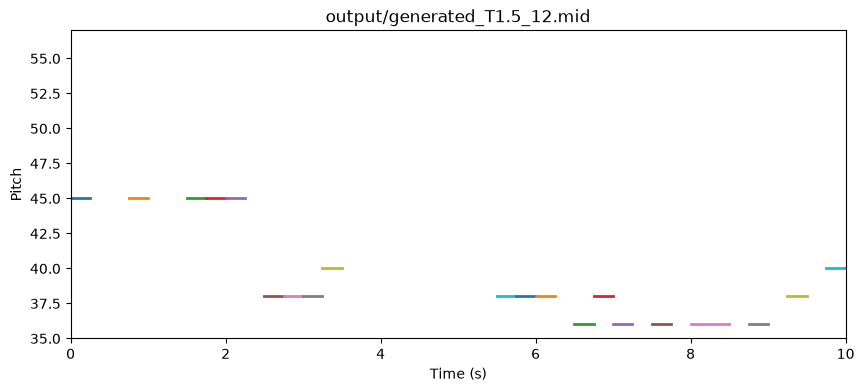

In [154]:
print("Example of the generated midi file with temperature 1.5")
generated_midi_file = "output/generated_T1.5_12.mid"
midi = pretty_midi.PrettyMIDI(str(generated_midi_file))
for instrument in midi.instruments:
    instrument.name = example_midi.instruments[0].name
    instrument.program = example_midi.instruments[0].program
midi.write(str(generated_midi_file))
play_for_10_seconds(generated_midi_file)
plot_midi(generated_midi_file)

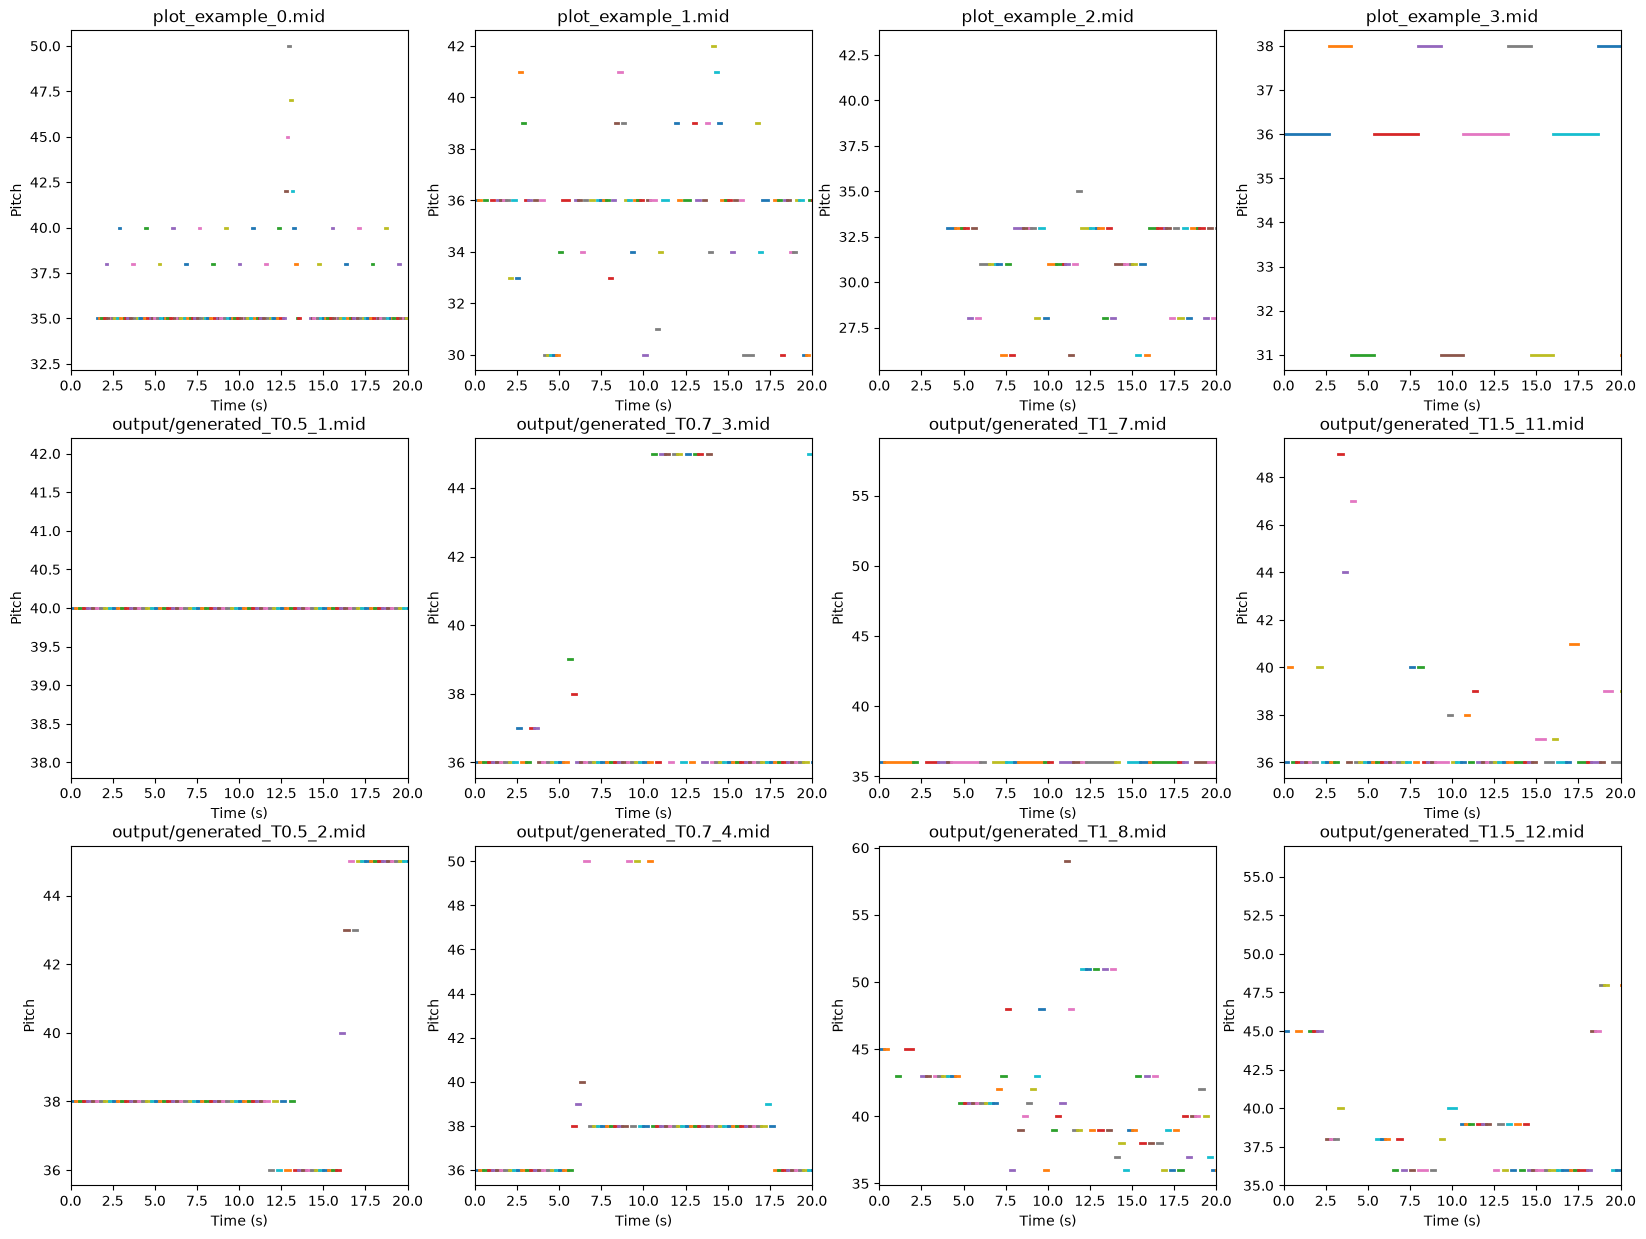

In [ ]:
for i in range(4):
    midi_file = metadata.loc[metadata.valid, "path"].iloc[i]
    example_midi = pretty_midi.PrettyMIDI(str(midi_file))
    example_midi.instruments = [instrument for instrument in example_midi.instruments if instrument.notes and is_bass_instrument(instrument)]
    example_midi.instruments = example_midi.instruments[:1]
    example_midi.write(str(f'plot_example_{i}.mid'))
fig, ax = plt.subplots(3, 4, figsize=(20, 15))
for i in range(4):
    plot_midi_subplot(f'plot_example_{i}.mid', ax=ax[0, i])
plot_midi_subplot(f'output/generated_T0.5_1.mid', ax=ax[1, 0])
plot_midi_subplot(f'output/generated_T0.7_3.mid', ax=ax[1, 1])
plot_midi_subplot(f'output/generated_T1_7.mid', ax=ax[1, 2])
plot_midi_subplot(f'output/generated_T1.5_11.mid', ax=ax[1, 3])
plot_midi_subplot(f'output/generated_T0.5_2.mid', ax=ax[2, 0])
plot_midi_subplot(f'output/generated_T0.7_4.mid', ax=ax[2, 1])
plot_midi_subplot(f'output/generated_T1_8.mid', ax=ax[2, 2])
plot_midi_subplot(f'output/generated_T1.5_12.mid', ax=ax[2, 3])
plt.savefig(IMAGE_DIR / "visual_comparison.png")
plt.show()

